In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix

from sklearn.preprocessing import LabelEncoder

import joblib



In [2]:
# Note the addition of 'DELL' (or your specific username)
data = pd.read_csv(r"C:\Users\DELL\Desktop\Data-Resources (1)\Data & Resources\Data\Customer_Data.csv")

data.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,NaN,Yes,No,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Yes,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,NaN,Yes,No,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [3]:
import pandas as pd

# 1. Load the data properly (using your confirmed path)
path = r"C:\Users\DELL\Desktop\Data-Resources (1)\Data & Resources\Data\Customer_Data.csv"
df = pd.read_csv(path)

# 2. Clean column names (removes hidden spaces like ' Customer_ID')
df.columns = df.columns.str.strip()

# 3. Define the columns you want to drop
# Note: I'm adding variations like 'Customer ID' just in case there are no underscores
cols_to_drop = ['Customer_ID', 'Customer ID', 'Churn_Category', 'Churn Category', 'Churn_Reason', 'Churn Reason']

# 4. Drop only the ones that actually exist in your file
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 5. Verify it worked
print("Data loaded and columns dropped successfully!")
print(f"Remaining columns: {df.columns.tolist()}")
df.head()

Data loaded and columns dropped successfully!
Remaining columns: ['Gender', 'Age', 'Married', 'State', 'Number_of_Referrals', 'Tenure_in_Months', 'Value_Deal', 'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup', 'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies', 'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing', 'Payment_Method', 'Monthly_Charge', 'Total_Charges', 'Total_Refunds', 'Total_Extra_Data_Charges', 'Total_Long_Distance_Charges', 'Total_Revenue', 'Customer_Status']


,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,...,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status
0,Male,35,No,Delhi,7,27,NaN,Yes,No,Yes,...,One Year,Yes,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed
1,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Yes,Yes,...,Month-to-Month,No,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed
2,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,Yes,...,Month-to-Month,Yes,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned
3,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,Yes,...,Month-to-Month,Yes,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned
4,Female,80,No,Tamil Nadu,3,8,NaN,Yes,No,Yes,...,Month-to-Month,Yes,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned


In [4]:

# List of columns we WANT to remove
cols_to_remove = ['Customer_ID', 'Churn_Category', 'Churn_Reason']

# Drop ONLY the ones that actually exist in the data right now
data = data.drop(columns=[c for c in cols_to_remove if c in data.columns])



In [5]:
print(data.columns.tolist())

['Gender', 'Age', 'Married', 'State', 'Number_of_Referrals', 'Tenure_in_Months', 'Value_Deal', 'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup', 'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies', 'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing', 'Payment_Method', 'Monthly_Charge', 'Total_Charges', 'Total_Refunds', 'Total_Extra_Data_Charges', 'Total_Long_Distance_Charges', 'Total_Revenue', 'Customer_Status']


In [6]:

# List of columns to be label encoded

columns_to_encode = [

    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',

    'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',

    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies',

    'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',

    'Payment_Method'

]

In [7]:

# Encode categorical variables except the target variable

label_encoders = {}

for column in columns_to_encode:

    label_encoders[column] = LabelEncoder()

    data[column] = label_encoders[column].fit_transform(data[column])

 

In [8]:

# Manually encode the target variable 'Customer_Status'

data['Customer_Status'] = data['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

 

In [9]:
# Split data into features and target

X = data.drop('Customer_Status', axis=1)

y = data['Customer_Status']

In [10]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

 

In [12]:

# 1. Check how many NaNs are in the target column
print(f"NaNs before cleaning: {data['Customer_Status'].isnull().sum()}")

# 2. Drop rows where the Target (Customer_Status) is missing
data = data.dropna(subset=['Customer_Status'])

# 3. Re-define X and y with the cleaned data
X = data.drop('Customer_Status', axis=1)
y = data['Customer_Status']

# 4. Re-split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"NaNs after cleaning: {y.isnull().sum()}")
print("Data re-split and ready for training!")

NaNs before cleaning: 411
NaNs after cleaning: 0
Data re-split and ready for training!


In [13]:

# Train the model

rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [14]:
# Evaluate Model
# Make predictions
y_pred = rf_model.predict(X_test)

In [15]:
# Evaluate the model

print("Confusion Matrix:")

print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")

print(classification_report(y_test, y_pred))

Confusion Matrix:
[[785  56]
 [134 227]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.93      0.89       841
         1.0       0.80      0.63      0.70       361

    accuracy                           0.84      1202
   macro avg       0.83      0.78      0.80      1202
weighted avg       0.84      0.84      0.84      1202



In [16]:

# Feature Selection using Feature Importance

importances = rf_model.feature_importances_

indices = np.argsort(importances)[::-1]


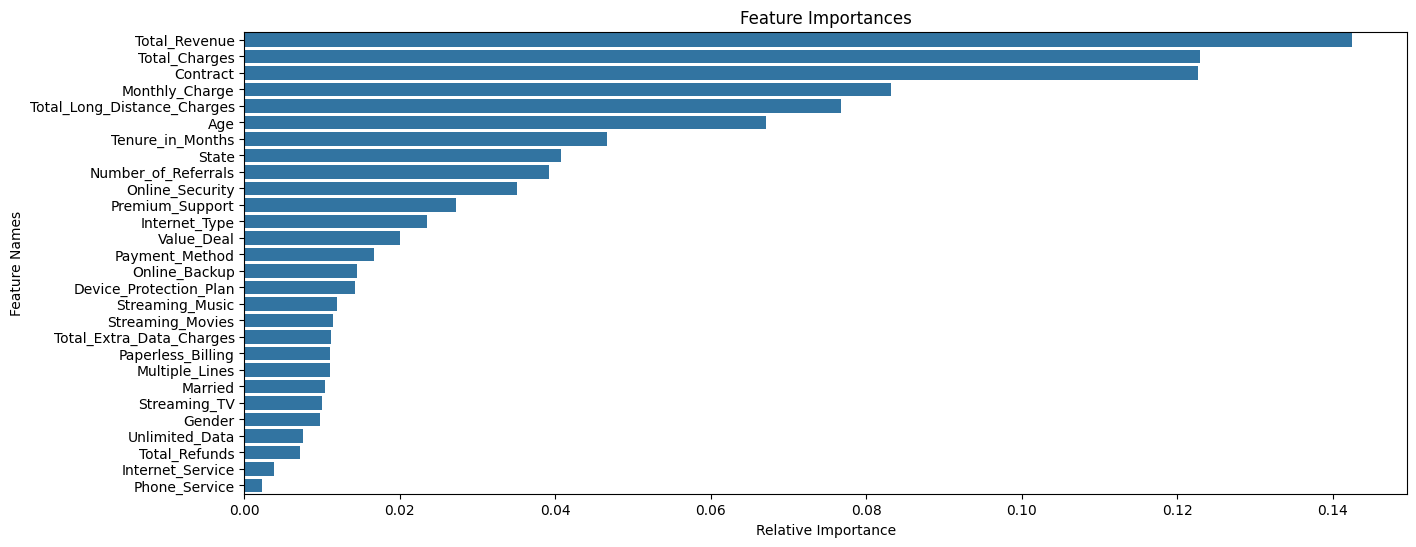

In [17]:
# Plot the feature importances

plt.figure(figsize=(15, 6))

sns.barplot(x=importances[indices], y=X.columns[indices])

plt.title('Feature Importances')

plt.xlabel('Relative Importance')

plt.ylabel('Feature Names')

plt.show()


In [39]:
import os
import pandas as pd
import numpy as np

# Path to your folder
file_path = r"C:\Users\DELL\Desktop\Data-Resources\Data & Resources\Data\Prediction_Data.xlsx"

if os.path.exists(file_path):
    print("✅ SUCCESS: File found! Fixing labels and generating report...")
    
    # 1. Load the Data
    new_data = pd.read_excel(file_path, sheet_name='vw_JoinData')
    original_data = new_data.copy()
    
    # 2. Prepare Data (Drop ID and target columns)
    cols_to_drop = ['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason']
    new_data_cleaned = new_data.drop(columns=[c for c in cols_to_drop if c in new_data.columns])
    
    # 3. ENCODE CATEGORIES (The "Bulletproof" Version)
    for column in new_data_cleaned.select_dtypes(include=['object']).columns:
        if column in label_encoders:
            # Convert everything to string and handle empty cells
            new_data_cleaned[column] = new_data_cleaned[column].astype(str).replace('nan', 'Unknown')
            
            # Identify what the AI actually knows
            known_labels = set(label_encoders[column].classes_.astype(str))
            
            # If the data has a word the AI doesn't know, replace it with the first label it DOES know
            fallback = list(known_labels)[0]
            new_data_cleaned[column] = new_data_cleaned[column].apply(lambda x: x if x in known_labels else fallback)
            
            # Transform without crashing
            new_data_cleaned[column] = label_encoders[column].transform(new_data_cleaned[column])
            
    # 4. Run the Prediction
    new_predictions = rf_model.predict(new_data_cleaned)
    original_data['Customer_Status_Predicted'] = new_predictions
    
    # 5. SAVE EVERYTHING (Fixes the "Empty Content" issue)
    output_path = r"C:\Users\DELL\Desktop\Data-Resources\Data & Resources\Data\Predictions.csv"
    
    # We save ALL rows. In Power BI, she can simply filter the 'Customer_Status_Predicted' column.
    original_data.to_csv(output_path, index=False)
    
    print(f"🚀 DONE! Report created with {len(original_data)} customers.")
    print("--- Prediction Summary ---")
    print(original_data['Customer_Status_Predicted'].value_counts())
    print(f"Find your file here: {output_path}")
else:
    print(f"❌ ERROR: File not found at: {file_path}")

✅ SUCCESS: File found! Fixing labels and generating report...
🚀 DONE! Report created with 411 customers.
--- Prediction Summary ---
Customer_Status_Predicted
1.0    397
0.0     14
Name: count, dtype: int64
Find your file here: C:\Users\DELL\Desktop\Data-Resources\Data & Resources\Data\Predictions.csv
